# Telco Customer Churn — Classification

**Dataset:** IBM Telco Customer Churn  
**Target:** Predict whether a customer will cancel their subscription (`Churn = Yes`)

## Project Overview

This is a **binary classification** problem — each customer either churns (1) or stays (0).  
We build a Logistic Regression model, evaluate it with business-relevant metrics,  
and explore how the decision threshold affects precision and recall.

**Why threshold matters:**  
Predicting churn is *asymmetric* — missing a churner (false negative) is costly  
but flagging every customer (false positive) wastes retention budget.

**Steps:**
1. Setup
2. Load and prepare data
3. Feature engineering and split
4. Baseline model
5. Logistic Regression pipeline
6. Confusion matrix
7. Classification report
8. Threshold analysis
9. Feature importance (coefficients)
10. Prediction table

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    f1_score, precision_score, recall_score, roc_auc_score
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


## 2. Load and Prepare the Data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges arrives as string — convert to numeric
# Customers with tenure=0 have blank TotalCharges → fill with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

print("Missing values after fix:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values after fix:
Series([], dtype: int64)


## 3. Feature Engineering and Train / Test Split

**Target:** `Churn` → encoded as 1 (churned) / 0 (stayed)

`customerID` is dropped — it's an arbitrary identifier that carries no  
predictive signal and would blow up dimensionality after encoding.

In [5]:
df["churned"] = (df["Churn"] == "Yes").astype(int)

X = df.drop(columns=["Churn", "churned", "customerID"])
y = df["churned"]

print("Class distribution:")
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain:", X_train.shape, "| Test:", X_test.shape)

Class distribution:
churned
0    0.735
1    0.265
Name: proportion, dtype: float64

Train: (5634, 19) | Test: (1409, 19)


## 4. Baseline Model — Always Predict the Majority Class

The simplest possible model predicts "No Churn" for everyone.  
This sets the floor our model must beat.

In [6]:
majority_class = y_train.mode()[0]
baseline_pred  = np.full(len(y_test), fill_value=majority_class)

print(f"Baseline always predicts: {majority_class} (majority class)")
print(f"  Accuracy : {(baseline_pred == y_test).mean():.3f}")
print(f"  F1 Score : {f1_score(y_test, baseline_pred):.3f}")
print(f"  Recall   : {recall_score(y_test, baseline_pred):.3f}")

Baseline always predicts: 0 (majority class)
  Accuracy : 0.735
  F1 Score : 0.000
  Recall   : 0.000


## 5. Logistic Regression Pipeline

The pipeline handles:
- **Numerical features** → median imputation + standard scaling
- **Categorical features** → mode imputation + one-hot encoding

Fitting everything inside a Pipeline ensures no leakage from test data.

In [7]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical  :", num_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_13012/2640416114.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [8]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)

proba = pipeline.predict_proba(X_test)[:, 1]  # churn probability
pred  = (proba >= 0.5).astype(int)            # default threshold

print("Model trained!")

Model trained!


## 6. Confusion Matrix

The confusion matrix breaks predictions into 4 categories:
- **TP** — correctly predicted churn
- **TN** — correctly predicted no churn
- **FP** — predicted churn, but customer stayed (wasted offer)
- **FN** — predicted no churn, but customer left (missed!)

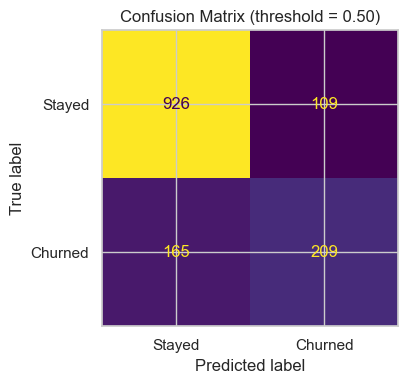

In [9]:
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Confusion Matrix (threshold = 0.50)")
plt.tight_layout()
plt.show()

## 7. Classification Report

| Metric | What it measures |
|---|---|
| **Precision** | Of all predicted churners, how many actually churned? |
| **Recall** | Of all actual churners, how many did we catch? |
| **F1** | Harmonic mean of precision and recall |
| **ROC-AUC** | Model's ability to rank churners above non-churners |

In [10]:
print(classification_report(y_test, pred, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, proba):.4f}")

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8421


## 8. Threshold Analysis

The default threshold of 0.5 is not always optimal.  
Lowering it **catches more churners** (higher recall) but flags more false alarms.  
Raising it **is more precise** but misses more real churners.

In [11]:
def evaluate_threshold(threshold):
    p = (proba >= threshold).astype(int)
    return {
        "threshold" : threshold,
        "precision" : precision_score(y_test, p, zero_division=0),
        "recall"    : recall_score(y_test, p),
        "f1"        : f1_score(y_test, p),
        "flagged_%" : round(p.mean() * 100, 1)
    }

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
threshold_df = pd.DataFrame([evaluate_threshold(t) for t in thresholds]).round(4)
threshold_df

,threshold,precision,recall,f1,flagged_%
0,0.2,0.4672,0.8556,0.6043,48.6
1,0.3,0.5193,0.7540,0.6150,38.5
2,0.4,0.5682,0.6684,0.6143,31.2
3,0.5,0.6572,0.5588,0.6040,22.6
4,0.6,0.7177,0.4011,0.5146,14.8
5,0.7,0.7419,0.1845,0.2955,6.6


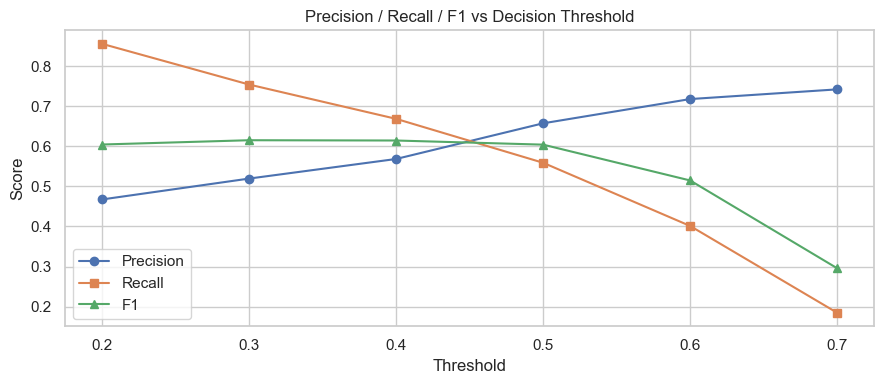

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"],    marker="s", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"],        marker="^", label="F1")
ax.set_title("Precision / Recall / F1 vs Decision Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance — Logistic Regression Coefficients

A positive coefficient increases the log-odds of churn;  
a negative one decreases it.  
Larger absolute values = stronger influence.

In [13]:
feature_names = pipeline.named_steps["prep"].get_feature_names_out()
coefs         = pipeline.named_steps["model"].coef_.ravel()

feat_df = pd.DataFrame({
    "feature"  : feature_names,
    "coef"     : coefs,
    "abs_coef" : np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("Top 10 most influential features:")
feat_df.head(10)

Top 10 most influential features:


,feature,coef,abs_coef
1,num__tenure,-1.257539,1.257539
38,cat__Contract_Two year,-0.776594,0.776594
15,cat__InternetService_DSL,-0.648646,0.648646
16,cat__InternetService_Fiber optic,0.634195,0.634195
2,num__MonthlyCharges,-0.591863,0.591863
36,cat__Contract_Month-to-month,0.582883,0.582883
3,num__TotalCharges,0.536253,0.536253
39,cat__PaperlessBilling_No,-0.343227,0.343227
22,cat__OnlineBackup_No internet service,-0.300104,0.300104
17,cat__InternetService_No,-0.300104,0.300104


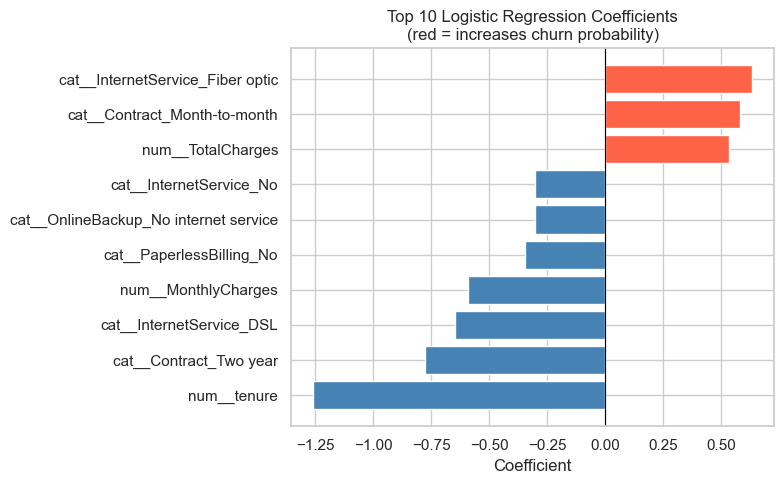

In [14]:
top10 = feat_df.head(10).sort_values("coef")

colors = ["tomato" if c > 0 else "steelblue" for c in top10["coef"]]
plt.figure(figsize=(8, 5))
plt.barh(top10["feature"], top10["coef"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 10 Logistic Regression Coefficients\n(red = increases churn probability)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## 10. Prediction Table — Sample Results

In [15]:
result_df = pd.DataFrame({
    "actual"       : y_test.values,
    "predicted"    : pred,
    "churn_prob"   : np.round(proba, 3),
    "correct"      : (pred == y_test.values)
}).reset_index(drop=True)

result_df.head(15)

,actual,predicted,churn_prob,correct
0,0,0,0.046,True
1,0,1,0.684,False
2,0,0,0.059,True
3,0,0,0.402,True
4,0,0,0.021,True
5,0,1,0.603,False
6,0,0,0.448,True
7,0,0,0.130,True
8,0,0,0.003,True
9,1,0,0.395,False


## Key Findings

| Finding | Detail |
|---|---|
| **Baseline F1** | ≈ 0.00 — majority class model catches no churners |
| **Model F1 (churn class)** | ≈ 0.58–0.62 at threshold 0.50 |
| **ROC-AUC** | ≈ 0.84 — model ranks churners well above non-churners |
| **Threshold 0.30** | Higher recall — catches more churners, more false alarms |
| **Top churn drivers** | Month-to-month contract, fiber optic service, electronic check payment |
| **Top retention signals** | Two-year contracts, low monthly charges, longer tenure |

> **Business recommendation:**  
> Use threshold 0.35–0.40 for proactive retention campaigns —  
> the cost of a missed churner typically exceeds the cost of an unnecessary offer.  
> Next step: Try a tree-based model (e.g. Random Forest or XGBoost) for higher recall.